In [1]:
from neuron_toolbox import *
import nest
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
nest.set_verbosity("M_WARNING")

params_parasol = {"tau_m": 8.0, "V_th": -52.0, "tau_syn_ex": 0.8}
params_midget = {"tau_m": 15.0, "V_th": -50.0, "tau_syn_ex": 1.5}
gsl = 64
grid_extent = [float(gsl), float(gsl)]
grid_shape = [gsl, gsl]



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jan 27 2025 08:17:55

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:


def preprocess_image_for_retina(image_array, target_size):
    """
    Nimmt ein beliebig großes Bild als NumPy-Array und skaliert es auf
    eine quadratische Zielgröße herunter.

    Args:
        image_array (np.ndarray): Das Input-Bild (z.B. aus Ihrem TCP-Stream).
                                  Erwartet ein 3-Kanal-Bild (Höhe, Breite, 3).
        target_size (int): Die Kantenlänge des quadratischen Zielbildes (z.B. gls).

    Returns:
        np.ndarray: Das auf die Zielgröße herunterskalierte Bild.
    """
    if image_array is None or image_array.size == 0:
        return np.zeros((target_size, target_size, 3), dtype=np.uint8)

    new_dimensions = (target_size, target_size)
    
    resized_image = cv2.resize(image_array, new_dimensions, interpolation=cv2.INTER_AREA)

    return resized_image

# Diese Funktion ist die mathematische Nachbildung der Center-Surround-Verarbeitung in der Retina.

def apply_dog_filter(image, center_sigma=1.0, surround_sigma=3.0):
    """
    Wendet einen Difference-of-Gaussians (DoG)-Filter auf ein Bild an,
    um ein Center-Surround-rezeptives Feld zu simulieren.

    Args:
        image (np.ndarray): Das Eingangsbild (bereits in Graustufen).
        center_sigma (float): Die 'Größe' des erregenden Zentrums.
        surround_sigma (float): Die 'Größe' des hemmenden Umfelds.

    Returns:
        np.ndarray: Eine Karte, bei der positive Werte ON-Regionen und
                    negative Werte OFF-Regionen entsprechen.
    """
    center = cv2.GaussianBlur(image, (0, 0), center_sigma)
    surround = cv2.GaussianBlur(image, (0, 0), surround_sigma)
    dog_image = center.astype(np.float32) - surround.astype(np.float32) #scharf - weichgezeichnet, idee geklaut.
    # im grunde, wenn bereich im center dunkler als umfeld ist, ist es ein OFF signal und eine neg. zahl
    # umgekehrt, ON signal, pos. zahl
    return dog_image

In [3]:

def create_retina_layer(grid_shape, grid_extent, params_midget, params_parasol):
    """
    Erstellt die gesamte RGC-Schicht des Modells, inklusive der Input-Generatoren,
    Neuronen-Populationen, Verbindungen und Spike-Rekorder.

    Args:
        grid_shape (list): Form des Gitters, z.B. [16, 16].
        grid_extent (list): Ausdehnung des Gitters, z.B. [16.0, 16.0].
        params_midget (dict): Parameter für Midget-Zellen.
        params_parasol (dict): Parameter für Parasol-Zellen.

    Returns:
        dict: Ein Dictionary, das die erstellten Populationen, Input-Generatoren
              und Rekorder enthält.
    """
    n_neurons = grid_shape[0] * grid_shape[1]
    
    positions = nest.spatial.grid(shape=grid_shape, extent=grid_extent)
    rgc_populations = {
        'parasol_on':  nest.Create("iaf_psc_alpha", params=params_parasol, positions=positions),
        'parasol_off': nest.Create("iaf_psc_alpha", params=params_parasol, positions=positions),
        'midget_on':   nest.Create("iaf_psc_alpha", params=params_midget, positions=positions),
        'midget_off':  nest.Create("iaf_psc_alpha", params=params_midget, positions=positions)
    }

    input_generators = {
        'on': nest.Create("poisson_generator", n_neurons, params={'rate': 0.0}),
        'off': nest.Create("poisson_generator", n_neurons, params={'rate': 0.0})
    }

    conn_spec = {'rule': 'one_to_one'}
    syn_spec = {'weight': 50.0}
    nest.Connect(input_generators['on'], rgc_populations['parasol_on'], conn_spec, syn_spec)
    nest.Connect(input_generators['on'], rgc_populations['midget_on'], conn_spec, syn_spec)
    nest.Connect(input_generators['off'], rgc_populations['parasol_off'], conn_spec, syn_spec)
    nest.Connect(input_generators['off'], rgc_populations['midget_off'], conn_spec, syn_spec)

    recorders = {name: nest.Create("spike_recorder") for name in rgc_populations}
    for name, rec in recorders.items():
        nest.Connect(rgc_populations[name], rec)

    print("Retina-Schicht erfolgreich aufgebaut.")
    
    return {
        "populations": rgc_populations,
        "generators": input_generators,
        "recorders": recorders
    }

In [4]:
# Block 2: Haupt-Setup-Funktion für den Retinogeniculate Pathway

def build_retinogeniculate_pathway(grid_shape, grid_extent, params_rrc, params_lgn, conn_specs_ret_lgn):
    """
    Erstellt den gesamten Retinogeniculate Pathway von den RGCs bis zum LGN.
    
    Args:
        grid_shape (list): Form des Gitters, z.B. [16, 16].
        grid_extent (list): Ausdehnung des Gitters in Grad.
        params_rrc (dict): Dictionary mit Parametern für 'midget' und 'parasol' RGCs.
        params_lgn (dict): Dictionary mit Parametern für 'magno' und 'parvo' LGN-Zellen.
        conn_specs_ret_lgn (dict): Dictionary mit den Verbindungs- und Synapsen-Spezifikationen.

    Returns:
        dict: Ein verschachteltes Dictionary mit allen erstellten NEST-Knoten.
    """
    n_neurons = grid_shape[0] * grid_shape[1]
    positions = nest.spatial.grid(shape=grid_shape, extent=grid_extent)

    # RGC-Schicht erstellen 
    rgc_populations = {
        'parasol_on':  nest.Create("iaf_psc_alpha", params=params_rrc['parasol'], positions=positions),
        'parasol_off': nest.Create("iaf_psc_alpha", params=params_rrc['parasol'], positions=positions),
        'midget_on':   nest.Create("iaf_psc_alpha", params=params_rrc['midget'], positions=positions),
        'midget_off':  nest.Create("iaf_psc_alpha", params=params_rrc['midget'], positions=positions)
    }
    
    # Input-Generatoren für RGCs erstellen & verbinden
    input_generators = {
        'on': nest.Create("poisson_generator", n_neurons, params={'rate': 0.0}),
        'off': nest.Create("poisson_generator", n_neurons, params={'rate': 0.0})
    }
    nest.Connect(input_generators['on'], rgc_populations['parasol_on'], {'rule': 'one_to_one'}, {'weight': 50.0})
    nest.Connect(input_generators['on'], rgc_populations['midget_on'], {'rule': 'one_to_one'}, {'weight': 50.0})
    nest.Connect(input_generators['off'], rgc_populations['parasol_off'], {'rule': 'one_to_one'}, {'weight': 50.0})
    nest.Connect(input_generators['off'], rgc_populations['midget_off'], {'rule': 'one_to_one'}, {'weight': 50.0})

    # LGN-Schicht erstellen 
    lgn_populations = {
        'layer_1_magno': nest.Create("iaf_psc_alpha", params=params_lgn['magno'], positions=positions),
        'layer_4_parvo': nest.Create("iaf_psc_alpha", params=params_lgn['parvo'], positions=positions),
        'layer_6_parvo': nest.Create("iaf_psc_alpha", params=params_lgn['parvo'], positions=positions)
    }

    # Retina mit LGN verbinden 
    # M-Pfad
    nest.Connect(rgc_populations["parasol_on"], lgn_populations["layer_1_magno"], conn_specs_ret_lgn['m_path_conn'], conn_specs_ret_lgn['m_path_syn'])
    nest.Connect(rgc_populations["parasol_off"], lgn_populations["layer_1_magno"], conn_specs_ret_lgn['m_path_conn'], conn_specs_ret_lgn['m_path_syn'])
    # P-Pfad
    nest.Connect(rgc_populations["midget_on"], lgn_populations["layer_4_parvo"], conn_specs_ret_lgn['p_path_conn'], conn_specs_ret_lgn['p_path_syn'])
    nest.Connect(rgc_populations["midget_off"], lgn_populations["layer_4_parvo"], conn_specs_ret_lgn['p_path_conn'], conn_specs_ret_lgn['p_path_syn'])
    nest.Connect(rgc_populations["midget_on"], lgn_populations["layer_6_parvo"], conn_specs_ret_lgn['p_path_conn'], conn_specs_ret_lgn['p_path_syn'])
    nest.Connect(rgc_populations["midget_off"], lgn_populations["layer_6_parvo"], conn_specs_ret_lgn['p_path_conn'], conn_specs_ret_lgn['p_path_syn'])

    rgc_recorders = {name: nest.Create("spike_recorder") for name in rgc_populations}
    for name, rec in rgc_recorders.items():
        nest.Connect(rgc_populations[name], rec)
        
    lgn_recorders = {name: nest.Create("spike_recorder") for name in lgn_populations}
    for name, rec in lgn_recorders.items():
        nest.Connect(lgn_populations[name], rec)

    print("Kompletter Retinogeniculate Pathway aufgebaut.")
    
    return {
        "retina": {"populations": rgc_populations, "generators": input_generators, "recorders": rgc_recorders},
        "lgn": {"populations": lgn_populations, "recorders": lgn_recorders}
    }

In [5]:
def update_rgc_input(image_array, input_generators, target_size, max_rate=1000.0):
    """
    Aktualisiert die Raten der Poisson-Generatoren basierend auf einem Bild.
    """
    processed_image = preprocess_image_for_retina(image_array, target_size)
    gray_image = cv2.cvtColor(processed_image, cv2.COLOR_BGR2GRAY)
    dog_response = apply_dog_filter(gray_image)
    on_rates = np.maximum(0, dog_response.flatten()) * max_rate
    off_rates = np.maximum(0, -dog_response.flatten()) * max_rate
    nest.SetStatus(input_generators['on'], [{'rate': r} for r in on_rates])
    nest.SetStatus(input_generators['off'], [{'rate': r} for r in off_rates])

Retina-Schicht erfolgreich aufgebaut.


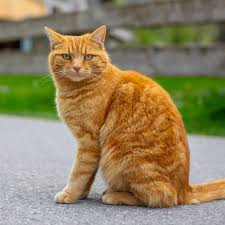

In [6]:
# Test auf anderem Input
retina = create_retina_layer(grid_shape, grid_extent, params_midget, params_parasol)

im = Image.open("cat.jpeg")
im


Update der RGC-Inputs mit dem Katzenbild...
Simulation abgeschlossen.


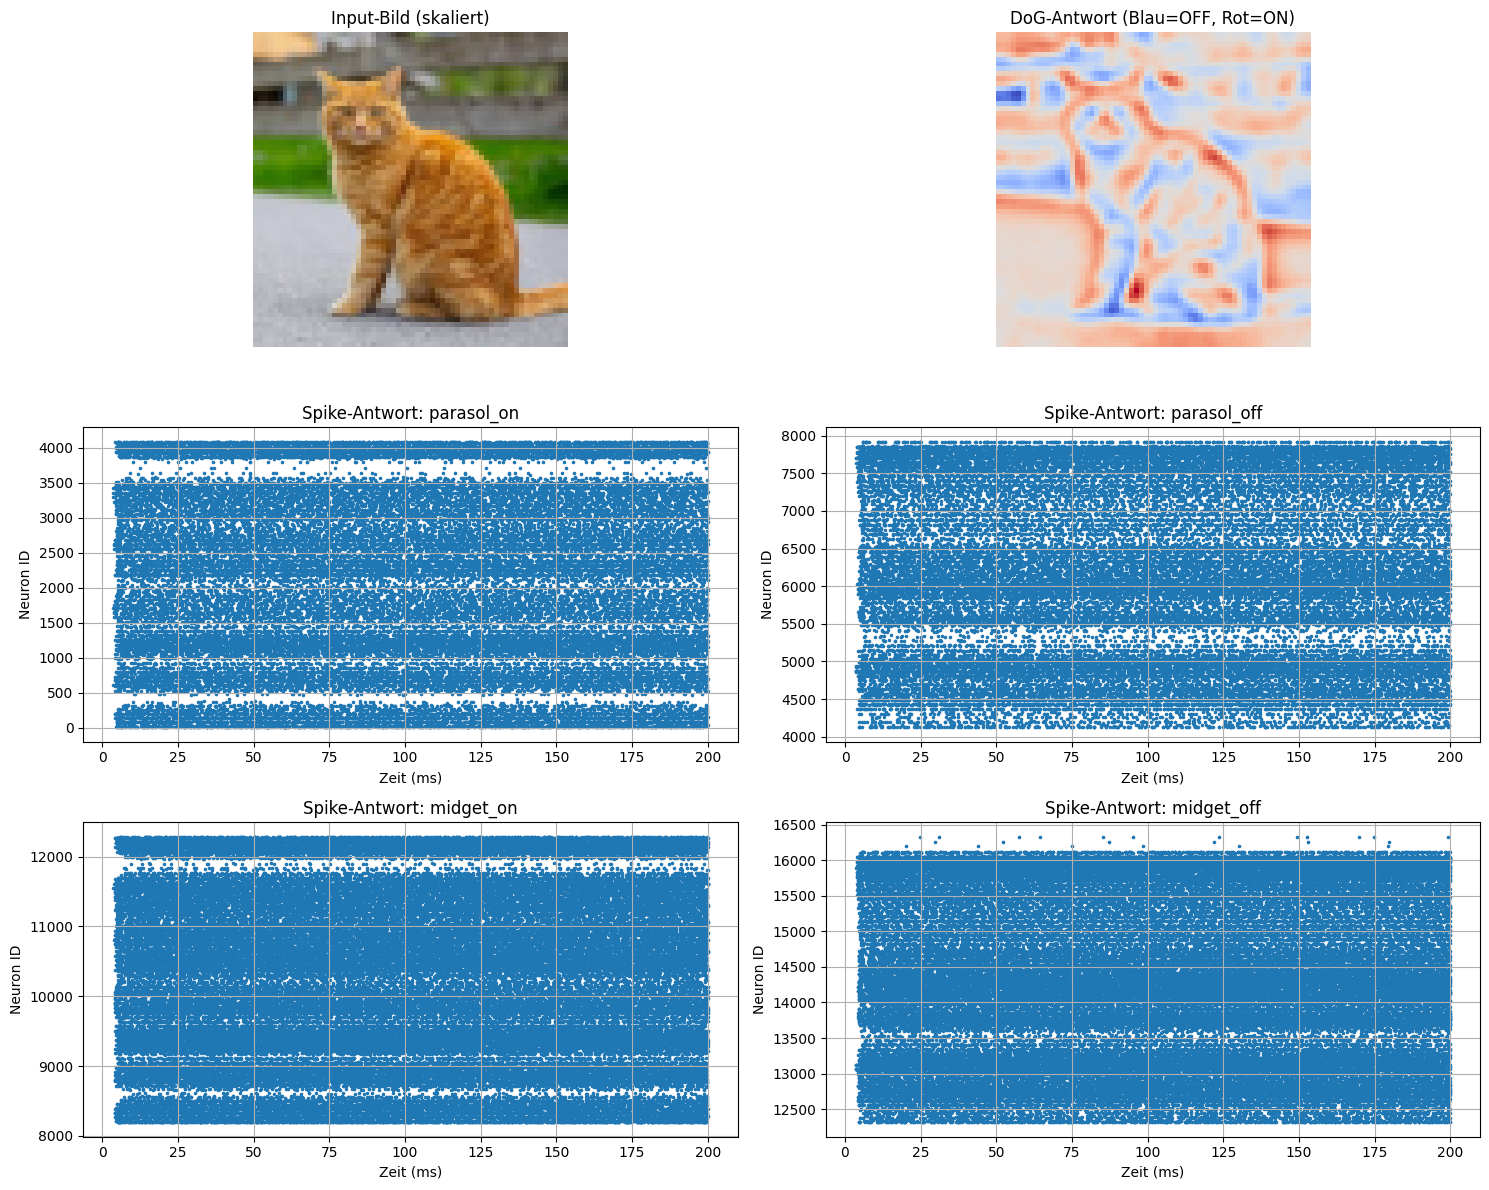

In [7]:
# Simulation Retina

image_np_rgb = np.array(im)
image_np_bgr = cv2.cvtColor(image_np_rgb, cv2.COLOR_RGB2BGR)

# Input setzen (die Funktion braucht jetzt die 'generators' aus unserem retina-Dict)
print("\nUpdate der RGC-Inputs mit dem Katzenbild...")
update_rgc_input(image_np_bgr, retina["generators"], target_size=gsl)

# Simulation laufen lassen
nest.Simulate(200.0)
print("Simulation abgeschlossen.")



plt.figure(figsize=(15, 12))
plt.subplot(3, 2, 1)
plt.imshow(cv2.cvtColor(preprocess_image_for_retina(image_np_bgr, gsl), cv2.COLOR_BGR2RGB))
plt.title("Input-Bild (skaliert)")
plt.axis('off')

gray_image = cv2.cvtColor(preprocess_image_for_retina(image_np_bgr, gsl), cv2.COLOR_BGR2GRAY)
dog_response = apply_dog_filter(gray_image)
plt.subplot(3, 2, 2)
plt.imshow(dog_response, cmap='coolwarm')
plt.title("DoG-Antwort (Blau=OFF, Rot=ON)")
plt.axis('off')

for i, (name, rec) in enumerate(retina["recorders"].items()):
    ax = plt.subplot(3, 2, i + 3)
    events = nest.GetStatus(rec, "events")[0]
    ax.scatter(events['times'], events['senders'], marker='.', s=10)
    ax.set_title(f"Spike-Antwort: {name}")
    ax.set_xlabel("Zeit (ms)")
    ax.set_ylabel("Neuron ID")
    ax.grid(True)

plt.tight_layout()
plt.show()

Retina-Schicht erfolgreich aufgebaut.
Baue den kompletten Retinogeniculate Pathway auf...
Kompletter Retinogeniculate Pathway aufgebaut.
--------------------
Update der RGC-Inputs mit dem cat-pic-nick...
Simulation abgeschlossen.
Visualisiere die Aktivität...


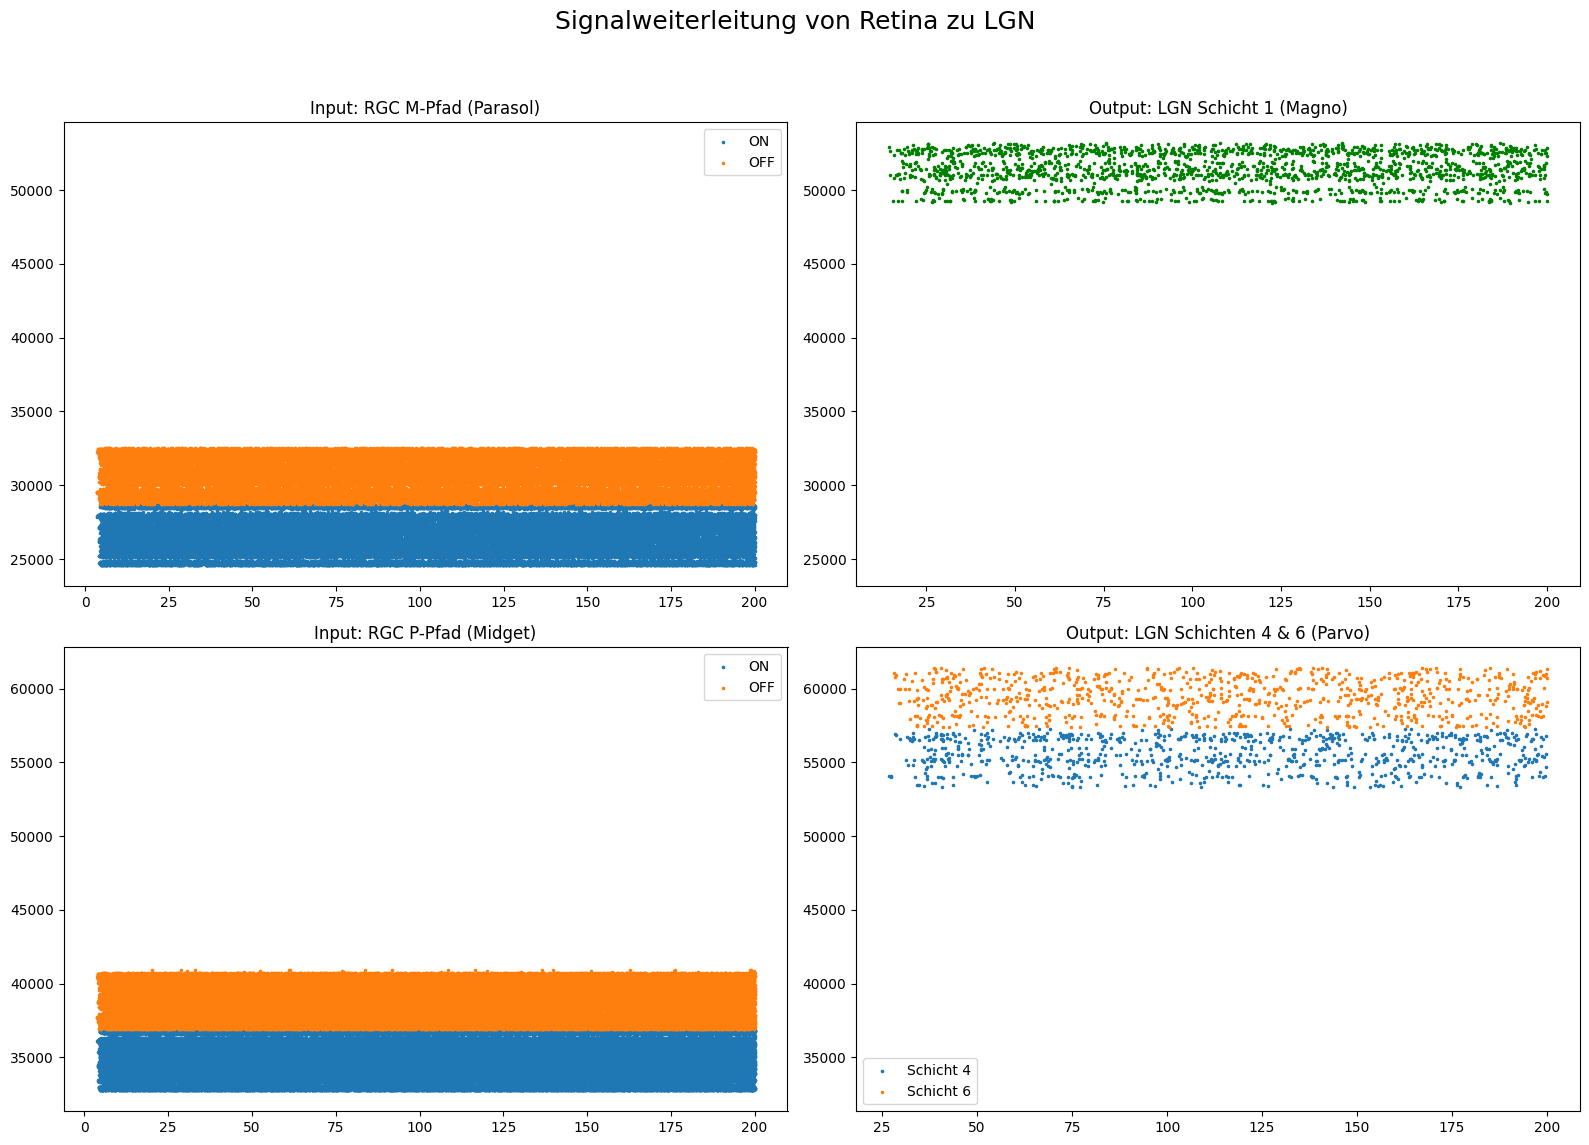

In [8]:
nest.ResetKernel()
# Grid-Parameter
grid_shape = [gsl, gsl]
grid_extent = [float(gsl), float(gsl)]
retina = create_retina_layer(grid_shape, grid_extent, params_midget, params_parasol)

params_rrc = {
    'parasol': {"tau_m": 8.0, "V_th": -52.0, "tau_syn_ex": 0.8},
    'midget': {"tau_m": 15.0, "V_th": -50.0, "tau_syn_ex": 1.5}
}
params_lgn = {
    'magno': {"tau_m": 9.0, "V_th": -54.0, "tau_syn_ex": 0.9}, # von -53.0 auf -54.0
    'parvo': {"tau_m": 16.0, "V_th": -52.0, "tau_syn_ex": 1.6}  # von -51.0 auf -52.0
}

conn_specs_ret_lgn = {
    'm_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.5, 'mask': {'circular': {'radius': 2.5}}},
    'p_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.75, 'mask': {'circular': {'radius': 1.0}}},
    'm_path_syn': {'weight': 80.0, 'delay': 1.2},
    'p_path_syn': {'weight': 50.0, 'delay': 1.2}
}

print("Baue den kompletten Retinogeniculate Pathway auf...")
pathway = build_retinogeniculate_pathway(grid_shape, grid_extent, params_rrc, params_lgn, conn_specs_ret_lgn)
print("-" * 20)


# Bild laden
try:
    im = Image.open("cat.jpeg")
    image_np_bgr = cv2.cvtColor(np.array(im), cv2.COLOR_RGB2BGR)

    # Input setzen (die Funktion greift auf das 'generators'-Dict im 'pathway'-Objekt zu)
    print("Update der RGC-Inputs mit dem cat-pic-nick...")
    update_rgc_input(image_np_bgr, pathway["retina"]["generators"], target_size=gsl)

    nest.Simulate(200.0)
    print("Simulation abgeschlossen.")

    print("Visualisiere die Aktivität...")
    plt.figure(figsize=(16, 12))
    plt.suptitle("Signalweiterleitung von Retina zu LGN", fontsize=18)

    # Plot für RGC M-Pfad
    ax1 = plt.subplot(2, 2, 1)
    events_on = nest.GetStatus(pathway["retina"]["recorders"]["parasol_on"], "events")[0]
    events_off = nest.GetStatus(pathway["retina"]["recorders"]["parasol_off"], "events")[0]
    ax1.scatter(events_on['times'], events_on['senders'], marker='.', s=10, label='ON')
    ax1.scatter(events_off['times'], events_off['senders'], marker='.', s=10, label='OFF')
    ax1.set_title("Input: RGC M-Pfad (Parasol)")
    ax1.legend()

    # Plot für LGN M-Pfad
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    events = nest.GetStatus(pathway["lgn"]["recorders"]["layer_1_magno"], "events")[0]
    ax2.scatter(events['times'], events['senders'], marker='.', s=10, c='green')
    ax2.set_title("Output: LGN Schicht 1 (Magno)")

    # Plot für RGC P-Pfad
    ax3 = plt.subplot(2, 2, 3)
    events_on = nest.GetStatus(pathway["retina"]["recorders"]["midget_on"], "events")[0]
    events_off = nest.GetStatus(pathway["retina"]["recorders"]["midget_off"], "events")[0]
    ax3.scatter(events_on['times'], events_on['senders'], marker='.', s=10, label='ON')
    ax3.scatter(events_off['times'], events_off['senders'], marker='.', s=10, label='OFF')
    ax3.set_title("Input: RGC P-Pfad (Midget)")
    ax3.legend()

    # Plot für LGN P-Pfad
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    events_4 = nest.GetStatus(pathway["lgn"]["recorders"]["layer_4_parvo"], "events")[0]
    events_6 = nest.GetStatus(pathway["lgn"]["recorders"]["layer_6_parvo"], "events")[0]
    ax4.scatter(events_4['times'], events_4['senders'], marker='.', s=10, label='Schicht 4')
    ax4.scatter(events_6['times'], events_6['senders'], marker='.', s=10, label='Schicht 6')
    ax4.set_title("Output: LGN Schichten 4 & 6 (Parvo)")
    ax4.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError:
    print("\nFEHLER: Die Datei 'cat.jpeg' wurde nicht gefunden. Bitte stellen Sie sicher, dass sie im selben Verzeichnis liegt.")

In [9]:

def simulate_with_video(video_path, pathway, target_size, fps=60.0):
    """
    Öffnet eine Videodatei und verarbeitet sie Frame für Frame, wobei die
    Simulationszeit an die NEST-Auflösung UND den minimalen Delay angepasst wird.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Fehler: Konnte die Videodatei nicht öffnen: {video_path}")
        return


    resolution = nest.resolution
    min_delay = nest.min_delay


    sim_time_per_frame = 1000.0 / fps
    rounded_sim_time = round(sim_time_per_frame / min_delay) * min_delay

    if abs(rounded_sim_time - sim_time_per_frame) > 0.01:
         print(f"Hinweis: Framedauer von {sim_time_per_frame:.2f} ms auf {rounded_sim_time:.2f} ms gerundet, um zum minimalen Delay von {min_delay} ms zu passen.")

    frame_count = 0
    total_sim_time = 0.0

    print(f"\nStarte Videosimulation mit {fps} FPS...")
    print(f"Jeder Frame wird für {rounded_sim_time:.2f} ms simuliert.")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        update_rgc_input(frame, pathway["retina"]["generators"], target_size=target_size)
        nest.Simulate(rounded_sim_time)
        
        frame_count += 1
        total_sim_time += rounded_sim_time

    cap.release()
    print("-" * 20)
    print(f"Videosimulation abgeschlossen.")
    print(f"Verarbeitet: {frame_count} Frames")
    print(f"Gesamte simulierte Zeit: {total_sim_time:.2f} ms")



--- START: Simulation mit Video ---
Kompletter Retinogeniculate Pathway aufgebaut.
Hinweis: Framedauer von 16.67 ms auf 17.00 ms gerundet, um zum minimalen Delay von 1.0 ms zu passen.

Starte Videosimulation mit 60.0 FPS...
Jeder Frame wird für 17.00 ms simuliert.
--------------------
Videosimulation abgeschlossen.
Verarbeitet: 150 Frames
Gesamte simulierte Zeit: 2550.00 ms

Visualisiere die Aktivität über die gesamte Videodauer...


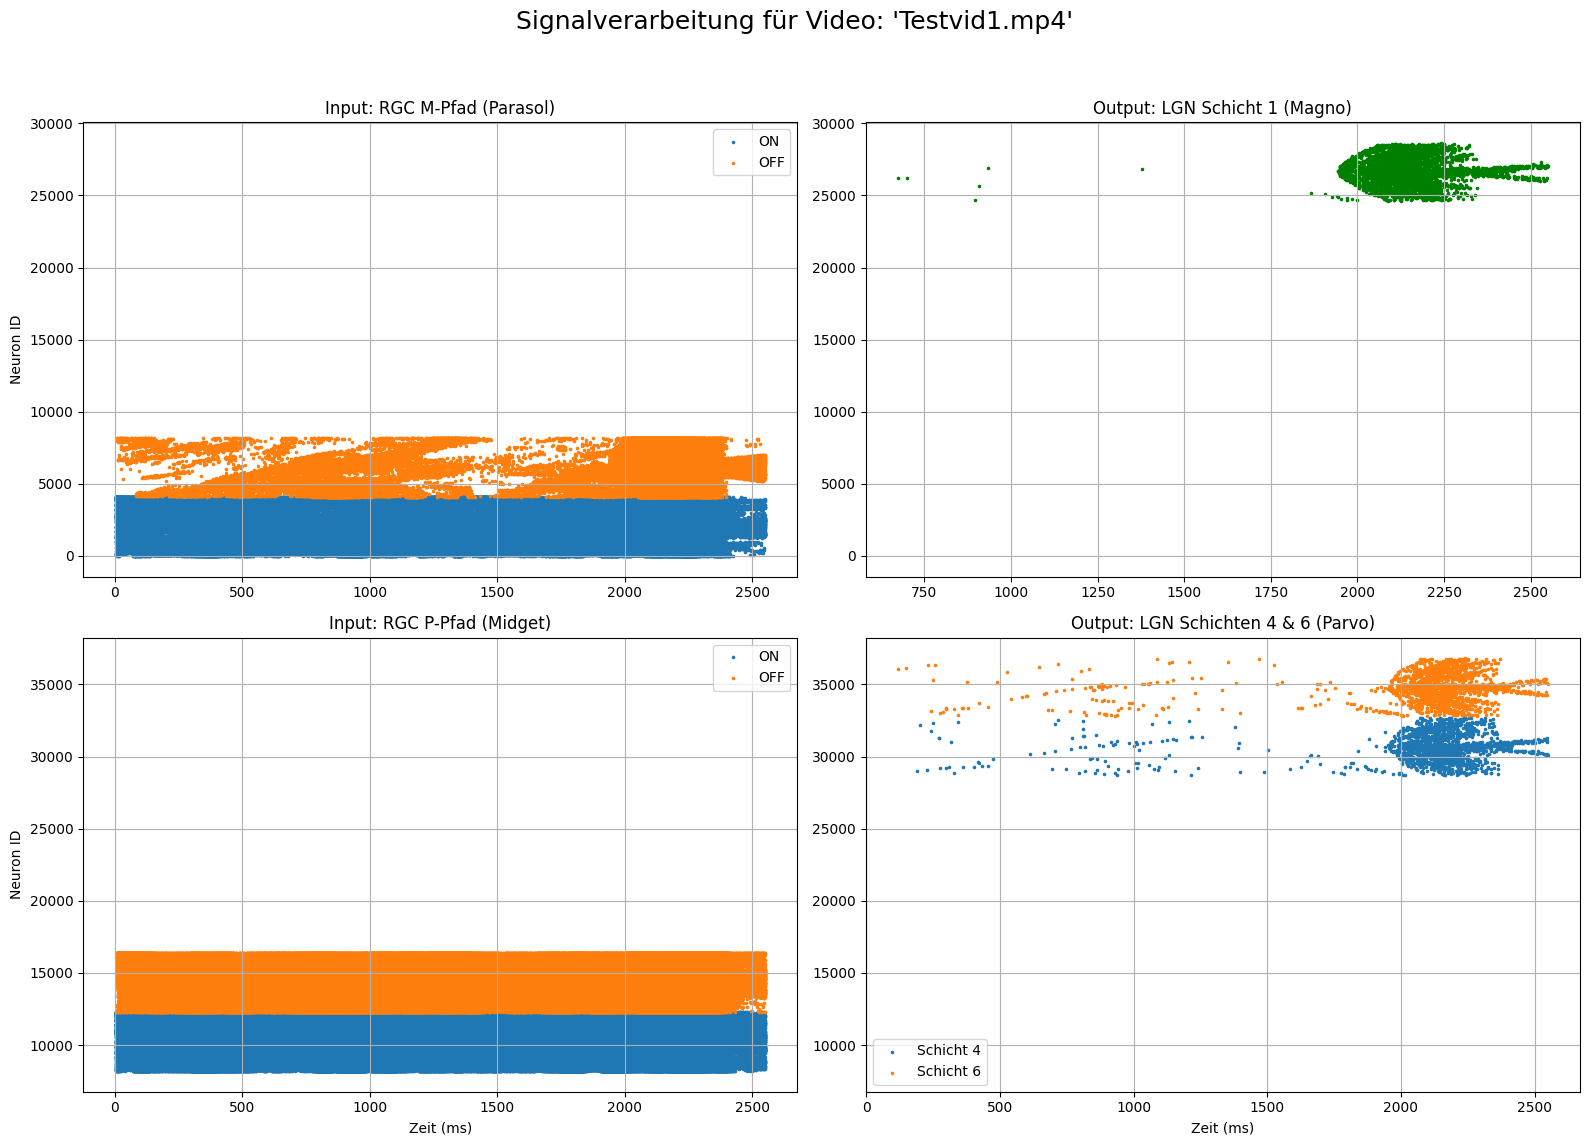

In [18]:
# Zelle für die Simulation mit Video (mit vollständigem Plotting)

print("\n\n--- START: Simulation mit Video ---")
nest.ResetKernel() 


grid_shape = [gsl, gsl]
grid_extent = [float(gsl), float(gsl)]
params_rrc = {
    'parasol': {"tau_m": 8.0, "V_th": -52.0, "tau_syn_ex": 0.8},
    'midget': {"tau_m": 15.0, "V_th": -50.0, "tau_syn_ex": 1.5}
}
params_lgn = {
    'magno': {"tau_m": 9.0, "V_th": -53.0, "tau_syn_ex": 0.9},
    'parvo': {"tau_m": 16.0, "V_th": -51.0, "tau_syn_ex": 1.6}
}
conn_specs_ret_lgn = {
    'm_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.5, 'mask': {'circular': {'radius': 2.5}}},
    'p_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.75, 'mask': {'circular': {'radius': 1.0}}},
    'm_path_syn': {'weight': 80.0, 'delay': 1.2},
    'p_path_syn': {'weight': 50.0, 'delay': 1.2}
}


pathway_video = build_retinogeniculate_pathway(grid_shape, grid_extent, params_rrc, params_lgn, conn_specs_ret_lgn)


video_file = "Testvid1.mp4" 
try:
    simulate_with_video(video_file, pathway_video, target_size=gsl, fps=60.0)

    print("\nVisualisiere die Aktivität über die gesamte Videodauer...")
    plt.figure(figsize=(16, 12))
    plt.suptitle(f"Signalverarbeitung für Video: '{video_file}'", fontsize=18)

    # Plot für RGC M-Pfad
    ax1 = plt.subplot(2, 2, 1)
    rec_on = pathway_video["retina"]["recorders"]["parasol_on"]
    rec_off = pathway_video["retina"]["recorders"]["parasol_off"]
    ax1.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax1.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax1.set_title("Input: RGC M-Pfad (Parasol)")
    ax1.set_ylabel("Neuron ID")
    ax1.legend()
    ax1.grid(True)

    # Plot für LGN M-Pfad
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    rec_lgn_m = pathway_video["lgn"]["recorders"]["layer_1_magno"]
    ax2.scatter(nest.GetStatus(rec_lgn_m, "events")[0]['times'], nest.GetStatus(rec_lgn_m, "events")[0]['senders'], marker='.', s=10, c='green')
    ax2.set_title("Output: LGN Schicht 1 (Magno)")
    ax2.grid(True)

    # Plot für RGC P-Pfad
    ax3 = plt.subplot(2, 2, 3)
    rec_on = pathway_video["retina"]["recorders"]["midget_on"]
    rec_off = pathway_video["retina"]["recorders"]["midget_off"]
    ax3.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax3.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax3.set_title("Input: RGC P-Pfad (Midget)")
    ax3.set_ylabel("Neuron ID")
    ax3.set_xlabel("Zeit (ms)")
    ax3.legend()
    ax3.grid(True)

    # Plot für LGN P-Pfad
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    rec_4 = pathway_video["lgn"]["recorders"]["layer_4_parvo"]
    rec_6 = pathway_video["lgn"]["recorders"]["layer_6_parvo"]
    ax4.scatter(nest.GetStatus(rec_4, "events")[0]['times'], nest.GetStatus(rec_4, "events")[0]['senders'], marker='.', s=10, label='Schicht 4')
    ax4.scatter(nest.GetStatus(rec_6, "events")[0]['times'], nest.GetStatus(rec_6, "events")[0]['senders'], marker='.', s=10, label='Schicht 6')
    ax4.set_title("Output: LGN Schichten 4 & 6 (Parvo)")
    ax4.set_xlabel("Zeit (ms)")
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError:
    print(f"\nFEHLER: Die Videodatei '{video_file}' wurde nicht gefunden. Bitte stellen Sie sicher, dass sie im selben Verzeichnis wie Ihr Notebook liegt.")



--- START: Simulation mit Video ---
Kompletter Retinogeniculate Pathway aufgebaut.
Hinweis: Framedauer von 16.67 ms auf 17.00 ms gerundet, um zum minimalen Delay von 1.0 ms zu passen.

Starte Videosimulation mit 60.0 FPS...
Jeder Frame wird für 17.00 ms simuliert.
--------------------
Videosimulation abgeschlossen.
Verarbeitet: 150 Frames
Gesamte simulierte Zeit: 2550.00 ms

Visualisiere die Aktivität über die gesamte Videodauer...


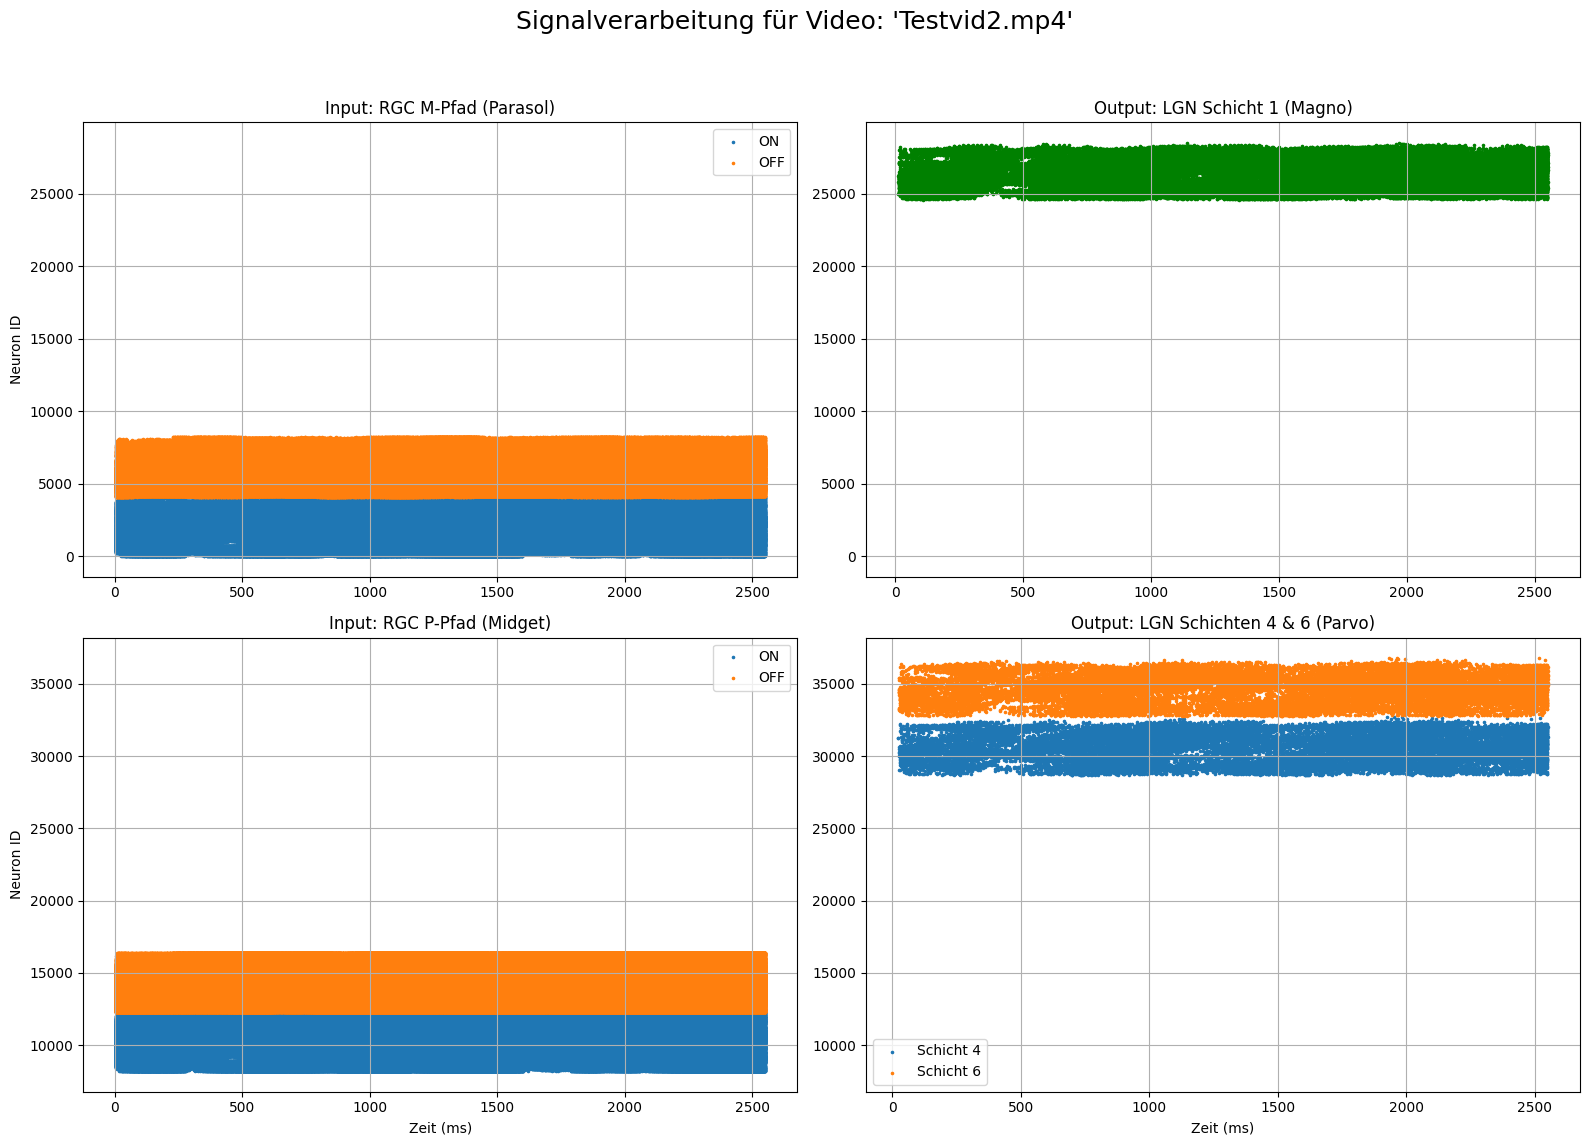

In [19]:
# Zelle für die Simulation mit Video (mit vollständigem Plotting)

print("\n\n--- START: Simulation mit Video ---")
nest.ResetKernel() 


grid_shape = [gsl, gsl]
grid_extent = [float(gsl), float(gsl)]
params_rrc = {
    'parasol': {"tau_m": 8.0, "V_th": -52.0, "tau_syn_ex": 0.8},
    'midget': {"tau_m": 15.0, "V_th": -50.0, "tau_syn_ex": 1.5}
}
params_lgn = {
    'magno': {"tau_m": 9.0, "V_th": -53.0, "tau_syn_ex": 0.9},
    'parvo': {"tau_m": 16.0, "V_th": -51.0, "tau_syn_ex": 1.6}
}
conn_specs_ret_lgn = {
    'm_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.5, 'mask': {'circular': {'radius': 2.5}}},
    'p_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.75, 'mask': {'circular': {'radius': 1.0}}},
    'm_path_syn': {'weight': 80.0, 'delay': 1.2},
    'p_path_syn': {'weight': 50.0, 'delay': 1.2}
}


pathway_video = build_retinogeniculate_pathway(grid_shape, grid_extent, params_rrc, params_lgn, conn_specs_ret_lgn)


video_file = "Testvid2.mp4" 
try:
    simulate_with_video(video_file, pathway_video, target_size=gsl, fps=60.0)

    print("\nVisualisiere die Aktivität über die gesamte Videodauer...")
    plt.figure(figsize=(16, 12))
    plt.suptitle(f"Signalverarbeitung für Video: '{video_file}'", fontsize=18)

    # Plot für RGC M-Pfad
    ax1 = plt.subplot(2, 2, 1)
    rec_on = pathway_video["retina"]["recorders"]["parasol_on"]
    rec_off = pathway_video["retina"]["recorders"]["parasol_off"]
    ax1.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax1.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax1.set_title("Input: RGC M-Pfad (Parasol)")
    ax1.set_ylabel("Neuron ID")
    ax1.legend()
    ax1.grid(True)

    # Plot für LGN M-Pfad
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    rec_lgn_m = pathway_video["lgn"]["recorders"]["layer_1_magno"]
    ax2.scatter(nest.GetStatus(rec_lgn_m, "events")[0]['times'], nest.GetStatus(rec_lgn_m, "events")[0]['senders'], marker='.', s=10, c='green')
    ax2.set_title("Output: LGN Schicht 1 (Magno)")
    ax2.grid(True)

    # Plot für RGC P-Pfad
    ax3 = plt.subplot(2, 2, 3)
    rec_on = pathway_video["retina"]["recorders"]["midget_on"]
    rec_off = pathway_video["retina"]["recorders"]["midget_off"]
    ax3.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax3.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax3.set_title("Input: RGC P-Pfad (Midget)")
    ax3.set_ylabel("Neuron ID")
    ax3.set_xlabel("Zeit (ms)")
    ax3.legend()
    ax3.grid(True)

    # Plot für LGN P-Pfad
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    rec_4 = pathway_video["lgn"]["recorders"]["layer_4_parvo"]
    rec_6 = pathway_video["lgn"]["recorders"]["layer_6_parvo"]
    ax4.scatter(nest.GetStatus(rec_4, "events")[0]['times'], nest.GetStatus(rec_4, "events")[0]['senders'], marker='.', s=10, label='Schicht 4')
    ax4.scatter(nest.GetStatus(rec_6, "events")[0]['times'], nest.GetStatus(rec_6, "events")[0]['senders'], marker='.', s=10, label='Schicht 6')
    ax4.set_title("Output: LGN Schichten 4 & 6 (Parvo)")
    ax4.set_xlabel("Zeit (ms)")
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError:
    print(f"\nFEHLER: Die Videodatei '{video_file}' wurde nicht gefunden. Bitte stellen Sie sicher, dass sie im selben Verzeichnis wie Ihr Notebook liegt.")



--- START: Simulation mit Video ---
Kompletter Retinogeniculate Pathway aufgebaut.
Hinweis: Framedauer von 16.67 ms auf 17.00 ms gerundet, um zum minimalen Delay von 1.0 ms zu passen.

Starte Videosimulation mit 60.0 FPS...
Jeder Frame wird für 17.00 ms simuliert.
--------------------
Videosimulation abgeschlossen.
Verarbeitet: 150 Frames
Gesamte simulierte Zeit: 2550.00 ms

Visualisiere die Aktivität über die gesamte Videodauer...


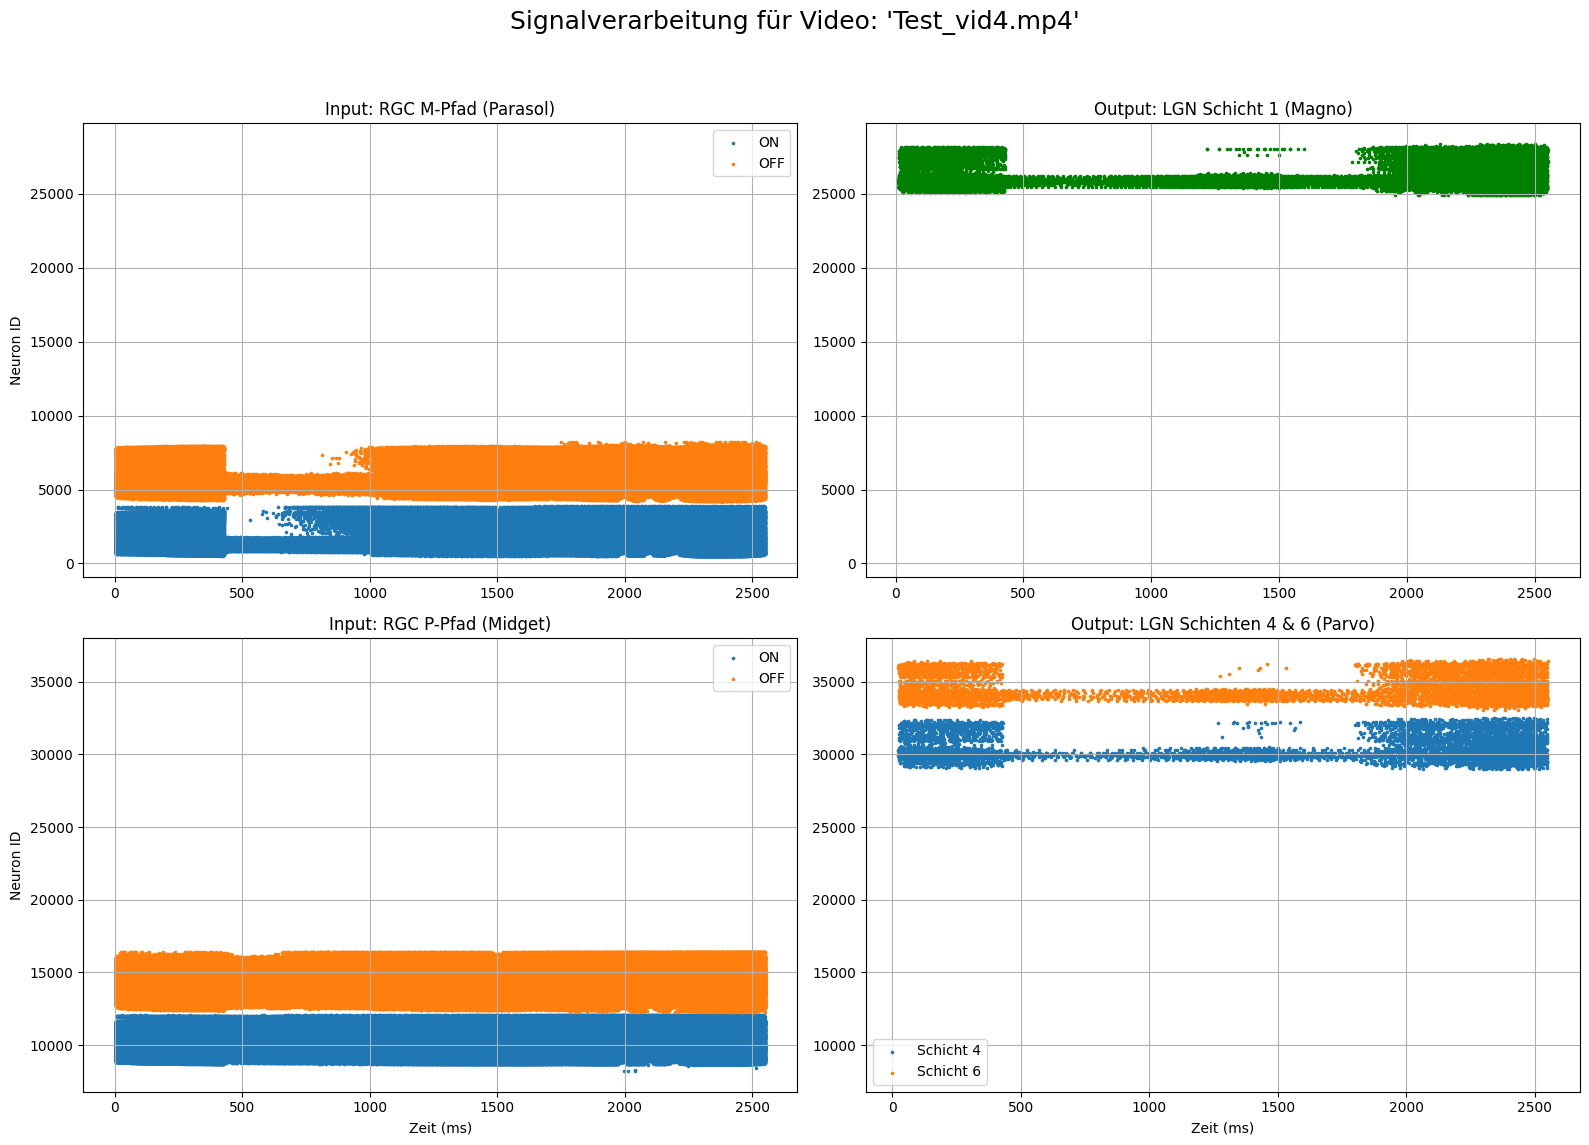

In [16]:
# Zelle für die Simulation mit Video (mit vollständigem Plotting)

print("\n\n--- START: Simulation mit Video ---")
nest.ResetKernel() 


grid_shape = [gsl, gsl]
grid_extent = [float(gsl), float(gsl)]
params_rrc = {
    'parasol': {"tau_m": 8.0, "V_th": -52.0, "tau_syn_ex": 0.8},
    'midget': {"tau_m": 15.0, "V_th": -50.0, "tau_syn_ex": 1.5}
}
params_lgn = {
    'magno': {"tau_m": 9.0, "V_th": -53.0, "tau_syn_ex": 0.9},
    'parvo': {"tau_m": 16.0, "V_th": -51.0, "tau_syn_ex": 1.6}
}
conn_specs_ret_lgn = {
    'm_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.5, 'mask': {'circular': {'radius': 2.5}}},
    'p_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.75, 'mask': {'circular': {'radius': 1.0}}},
    'm_path_syn': {'weight': 80.0, 'delay': 1.2},
    'p_path_syn': {'weight': 50.0, 'delay': 1.2}
}


pathway_video = build_retinogeniculate_pathway(grid_shape, grid_extent, params_rrc, params_lgn, conn_specs_ret_lgn)


video_file = "Test_vid4.mp4" 
try:
    simulate_with_video(video_file, pathway_video, target_size=gsl, fps=60.0)

    print("\nVisualisiere die Aktivität über die gesamte Videodauer...")
    plt.figure(figsize=(16, 12))
    plt.suptitle(f"Signalverarbeitung für Video: '{video_file}'", fontsize=18)

    # Plot für RGC M-Pfad
    ax1 = plt.subplot(2, 2, 1)
    rec_on = pathway_video["retina"]["recorders"]["parasol_on"]
    rec_off = pathway_video["retina"]["recorders"]["parasol_off"]
    ax1.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax1.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax1.set_title("Input: RGC M-Pfad (Parasol)")
    ax1.set_ylabel("Neuron ID")
    ax1.legend()
    ax1.grid(True)

    # Plot für LGN M-Pfad
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    rec_lgn_m = pathway_video["lgn"]["recorders"]["layer_1_magno"]
    ax2.scatter(nest.GetStatus(rec_lgn_m, "events")[0]['times'], nest.GetStatus(rec_lgn_m, "events")[0]['senders'], marker='.', s=10, c='green')
    ax2.set_title("Output: LGN Schicht 1 (Magno)")
    ax2.grid(True)

    # Plot für RGC P-Pfad
    ax3 = plt.subplot(2, 2, 3)
    rec_on = pathway_video["retina"]["recorders"]["midget_on"]
    rec_off = pathway_video["retina"]["recorders"]["midget_off"]
    ax3.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax3.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax3.set_title("Input: RGC P-Pfad (Midget)")
    ax3.set_ylabel("Neuron ID")
    ax3.set_xlabel("Zeit (ms)")
    ax3.legend()
    ax3.grid(True)

    # Plot für LGN P-Pfad
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    rec_4 = pathway_video["lgn"]["recorders"]["layer_4_parvo"]
    rec_6 = pathway_video["lgn"]["recorders"]["layer_6_parvo"]
    ax4.scatter(nest.GetStatus(rec_4, "events")[0]['times'], nest.GetStatus(rec_4, "events")[0]['senders'], marker='.', s=10, label='Schicht 4')
    ax4.scatter(nest.GetStatus(rec_6, "events")[0]['times'], nest.GetStatus(rec_6, "events")[0]['senders'], marker='.', s=10, label='Schicht 6')
    ax4.set_title("Output: LGN Schichten 4 & 6 (Parvo)")
    ax4.set_xlabel("Zeit (ms)")
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError:
    print(f"\nFEHLER: Die Videodatei '{video_file}' wurde nicht gefunden. Bitte stellen Sie sicher, dass sie im selben Verzeichnis wie Ihr Notebook liegt.")



--- START: Simulation mit Video ---
Kompletter Retinogeniculate Pathway aufgebaut.
Hinweis: Framedauer von 16.67 ms auf 17.00 ms gerundet, um zum minimalen Delay von 1.0 ms zu passen.

Starte Videosimulation mit 60.0 FPS...
Jeder Frame wird für 17.00 ms simuliert.
--------------------
Videosimulation abgeschlossen.
Verarbeitet: 150 Frames
Gesamte simulierte Zeit: 2550.00 ms

Visualisiere die Aktivität über die gesamte Videodauer...


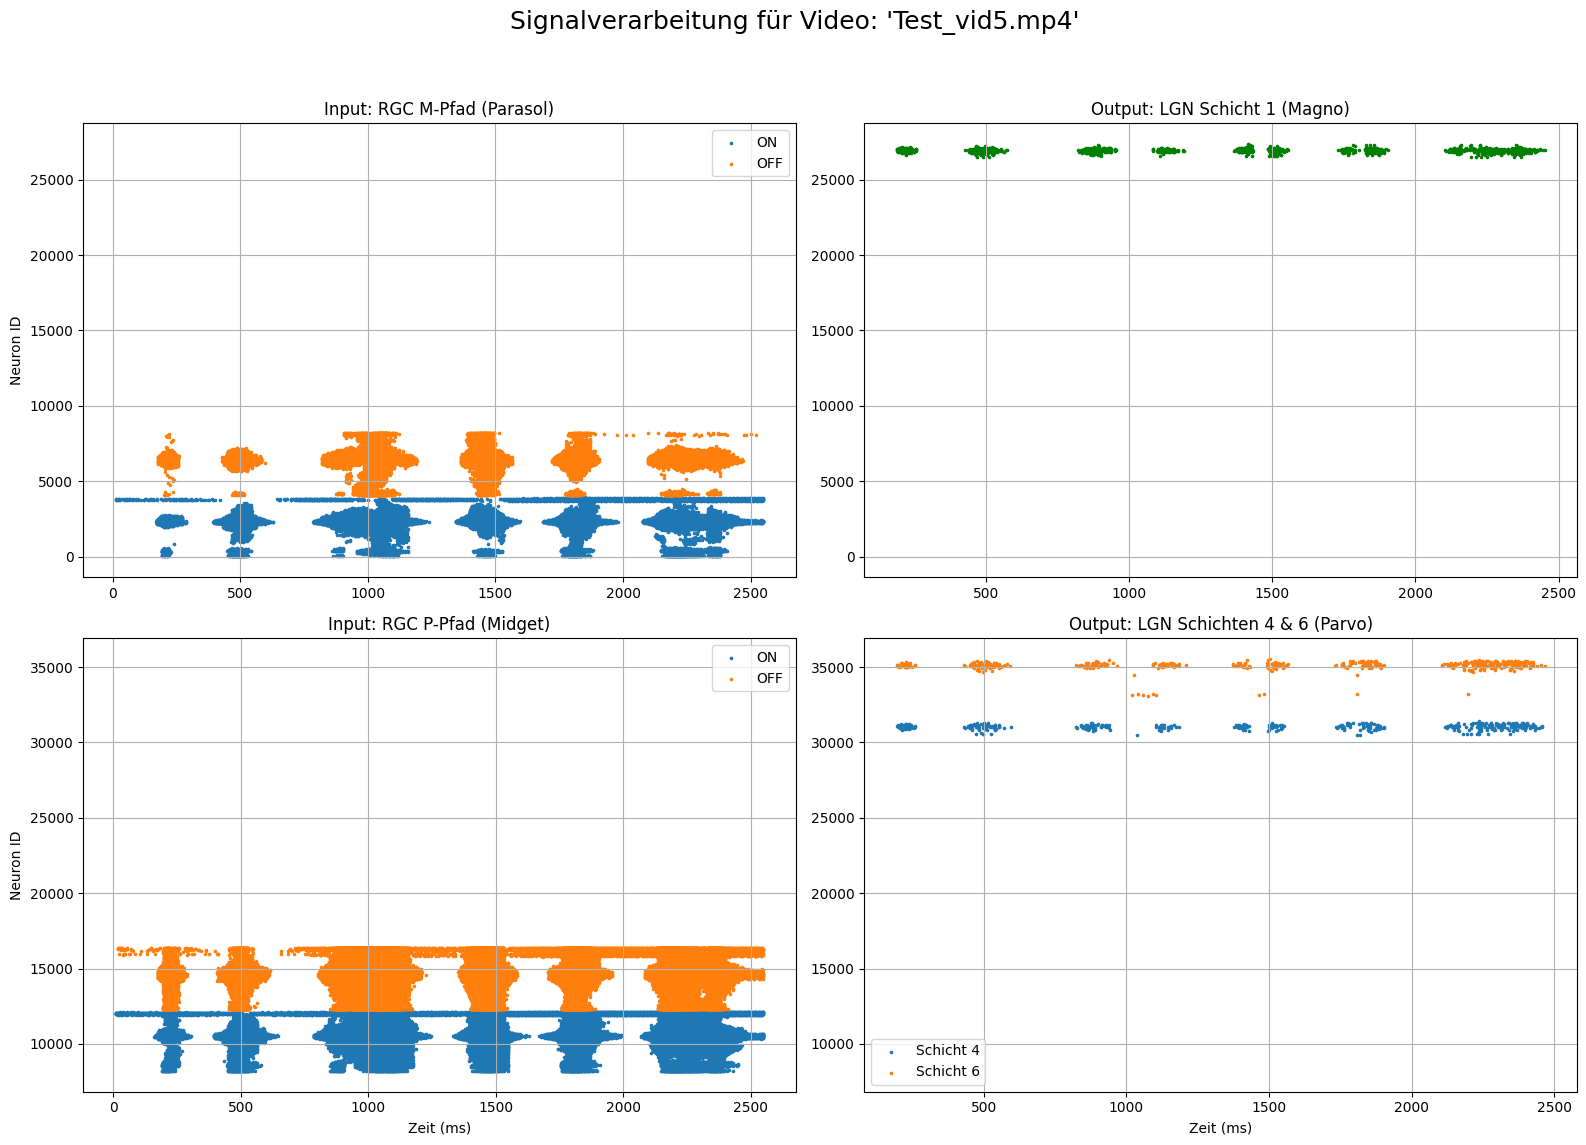

In [20]:
# Zelle für die Simulation mit Video (mit vollständigem Plotting)

print("\n\n--- START: Simulation mit Video ---")
nest.ResetKernel() 


grid_shape = [gsl, gsl]
grid_extent = [float(gsl), float(gsl)]
params_rrc = {
    'parasol': {"tau_m": 8.0, "V_th": -52.0, "tau_syn_ex": 0.8},
    'midget': {"tau_m": 15.0, "V_th": -50.0, "tau_syn_ex": 1.5}
}
params_lgn = {
    'magno': {"tau_m": 9.0, "V_th": -53.0, "tau_syn_ex": 0.9},
    'parvo': {"tau_m": 16.0, "V_th": -51.0, "tau_syn_ex": 1.6}
}
conn_specs_ret_lgn = {
    'm_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.5, 'mask': {'circular': {'radius': 2.5}}},
    'p_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.75, 'mask': {'circular': {'radius': 1.0}}},
    'm_path_syn': {'weight': 80.0, 'delay': 1.2},
    'p_path_syn': {'weight': 50.0, 'delay': 1.2}
}


pathway_video = build_retinogeniculate_pathway(grid_shape, grid_extent, params_rrc, params_lgn, conn_specs_ret_lgn)


video_file = "Test_vid5.mp4" 
try:
    simulate_with_video(video_file, pathway_video, target_size=gsl, fps=60.0)

    print("\nVisualisiere die Aktivität über die gesamte Videodauer...")
    plt.figure(figsize=(16, 12))
    plt.suptitle(f"Signalverarbeitung für Video: '{video_file}'", fontsize=18)

    # Plot für RGC M-Pfad
    ax1 = plt.subplot(2, 2, 1)
    rec_on = pathway_video["retina"]["recorders"]["parasol_on"]
    rec_off = pathway_video["retina"]["recorders"]["parasol_off"]
    ax1.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax1.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax1.set_title("Input: RGC M-Pfad (Parasol)")
    ax1.set_ylabel("Neuron ID")
    ax1.legend()
    ax1.grid(True)

    # Plot für LGN M-Pfad
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    rec_lgn_m = pathway_video["lgn"]["recorders"]["layer_1_magno"]
    ax2.scatter(nest.GetStatus(rec_lgn_m, "events")[0]['times'], nest.GetStatus(rec_lgn_m, "events")[0]['senders'], marker='.', s=10, c='green')
    ax2.set_title("Output: LGN Schicht 1 (Magno)")
    ax2.grid(True)

    # Plot für RGC P-Pfad
    ax3 = plt.subplot(2, 2, 3)
    rec_on = pathway_video["retina"]["recorders"]["midget_on"]
    rec_off = pathway_video["retina"]["recorders"]["midget_off"]
    ax3.scatter(nest.GetStatus(rec_on, "events")[0]['times'], nest.GetStatus(rec_on, "events")[0]['senders'], marker='.', s=10, label='ON')
    ax3.scatter(nest.GetStatus(rec_off, "events")[0]['times'], nest.GetStatus(rec_off, "events")[0]['senders'], marker='.', s=10, label='OFF')
    ax3.set_title("Input: RGC P-Pfad (Midget)")
    ax3.set_ylabel("Neuron ID")
    ax3.set_xlabel("Zeit (ms)")
    ax3.legend()
    ax3.grid(True)

    # Plot für LGN P-Pfad
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    rec_4 = pathway_video["lgn"]["recorders"]["layer_4_parvo"]
    rec_6 = pathway_video["lgn"]["recorders"]["layer_6_parvo"]
    ax4.scatter(nest.GetStatus(rec_4, "events")[0]['times'], nest.GetStatus(rec_4, "events")[0]['senders'], marker='.', s=10, label='Schicht 4')
    ax4.scatter(nest.GetStatus(rec_6, "events")[0]['times'], nest.GetStatus(rec_6, "events")[0]['senders'], marker='.', s=10, label='Schicht 6')
    ax4.set_title("Output: LGN Schichten 4 & 6 (Parvo)")
    ax4.set_xlabel("Zeit (ms)")
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError:
    print(f"\nFEHLER: Die Videodatei '{video_file}' wurde nicht gefunden. Bitte stellen Sie sicher, dass sie im selben Verzeichnis wie Ihr Notebook liegt.")

In [11]:
# Block 2 (Update): Haupt-Setup-Funktion für den gesamten Pathway bis V1

def build_visual_pathway(grid_shape, grid_extent, params_rrc, params_lgn, params_v1, conn_specs):
    """
    Erstellt den gesamten visuellen Feedforward-Pathway von den RGCs über das LGN
    bis zu den V1-Eingangsschichten.
    
    Args:
        (Argumente wie zuvor, plus...)
        params_v1 (dict): Parameter für V1-Neuronen.
        conn_specs (dict): Umfassendes Dict mit allen Konnektivitäts-Parametern.

    Returns:
        dict: Ein verschachteltes Dictionary mit allen erstellten NEST-Knoten.
    """
    n_neurons = grid_shape[0] * grid_shape[1]
    positions = nest.spatial.grid(shape=grid_shape, extent=grid_extent)
    
    rgc_populations = {
        'parasol_on': nest.Create("iaf_psc_alpha", params=params_rrc['parasol'], positions=positions),
        'parasol_off': nest.Create("iaf_psc_alpha", params=params_rrc['parasol'], positions=positions),
        'midget_on': nest.Create("iaf_psc_alpha", params=params_rrc['midget'], positions=positions),
        'midget_off': nest.Create("iaf_psc_alpha", params=params_rrc['midget'], positions=positions)
    }
    input_generators = {
        'on': nest.Create("poisson_generator", n_neurons, params={'rate': 0.0}),
        'off': nest.Create("poisson_generator", n_neurons, params={'rate': 0.0})
    }
    nest.Connect(input_generators['on'], rgc_populations['parasol_on'], {'rule': 'one_to_one'}, {'weight': 50.0})
    nest.Connect(input_generators['on'], rgc_populations['midget_on'], {'rule': 'one_to_one'}, {'weight': 50.0})
    nest.Connect(input_generators['off'], rgc_populations['parasol_off'], {'rule': 'one_to_one'}, {'weight': 50.0})
    nest.Connect(input_generators['off'], rgc_populations['midget_off'], {'rule': 'one_to_one'}, {'weight': 50.0})

    lgn_populations = {
        'layer_1_magno': nest.Create("iaf_psc_alpha", params=params_lgn['magno'], positions=positions),
        'layer_4_parvo': nest.Create("iaf_psc_alpha", params=params_lgn['parvo'], positions=positions),
        'layer_6_parvo': nest.Create("iaf_psc_alpha", params=params_lgn['parvo'], positions=positions)
    }
    nest.Connect(rgc_populations["parasol_on"], lgn_populations["layer_1_magno"], conn_specs['ret_lgn']['m_path_conn'], conn_specs['ret_lgn']['m_path_syn'])
    nest.Connect(rgc_populations["parasol_off"], lgn_populations["layer_1_magno"], conn_specs['ret_lgn']['m_path_conn'], conn_specs['ret_lgn']['m_path_syn'])
    nest.Connect(rgc_populations["midget_on"], lgn_populations["layer_4_parvo"], conn_specs['ret_lgn']['p_path_conn'], conn_specs['ret_lgn']['p_path_syn'])
    nest.Connect(rgc_populations["midget_off"], lgn_populations["layer_4_parvo"], conn_specs['ret_lgn']['p_path_conn'], conn_specs['ret_lgn']['p_path_syn'])
    nest.Connect(rgc_populations["midget_on"], lgn_populations["layer_6_parvo"], conn_specs['ret_lgn']['p_path_conn'], conn_specs['ret_lgn']['p_path_syn'])
    nest.Connect(rgc_populations["midget_off"], lgn_populations["layer_6_parvo"], conn_specs['ret_lgn']['p_path_conn'], conn_specs['ret_lgn']['p_path_syn'])

    # V1
    print("Erstelle V1-Eingangsschichten...")
    v1_populations = {
        'layer_4C_alpha': nest.Create("iaf_psc_alpha", params=params_v1, positions=positions),
        'layer_4C_beta':  nest.Create("iaf_psc_alpha", params=params_v1, positions=positions)
    }

    print("Verbinde LGN mit V1 (Geniculocorticale Projektion)...")
    # M-Pfad (LGN Magno -> V1 4C-alpha)
    nest.Connect(lgn_populations['layer_1_magno'], v1_populations['layer_4C_alpha'], conn_specs['lgn_v1'], conn_specs['lgn_v1_syn'])
    
    # P-Pfad (LGN Parvo -> V1 4C-beta)
    nest.Connect(lgn_populations['layer_4_parvo'], v1_populations['layer_4C_beta'], conn_specs['lgn_v1'], conn_specs['lgn_v1_syn'])
    nest.Connect(lgn_populations['layer_6_parvo'], v1_populations['layer_4C_beta'], conn_specs['lgn_v1'], conn_specs['lgn_v1_syn'])

    
    rgc_recorders = {name: nest.Create("spike_recorder") for name in rgc_populations}
    for name, rec in rgc_recorders.items():
        nest.Connect(rgc_populations[name], rec)
        
    lgn_recorders = {name: nest.Create("spike_recorder") for name in lgn_populations}
    for name, rec in lgn_recorders.items():
        nest.Connect(lgn_populations[name], rec)

    # Rekorder für V1
    v1_recorders = {name: nest.Create("spike_recorder") for name in v1_populations}
    for name, rec in v1_recorders.items():
        nest.Connect(v1_populations[name], rec)

    print("Kompletter Pathway bis V1 aufgebaut.")
    
    return {
        "retina": {"populations": rgc_populations, "generators": input_generators, "recorders": rgc_recorders},
        "lgn": {"populations": lgn_populations, "recorders": lgn_recorders},
        "v1": {"populations": v1_populations, "recorders": v1_recorders}
    }

Baue den kompletten visuellen Pathway bis V1 auf...
Erstelle V1-Eingangsschichten...
Verbinde LGN mit V1 (Geniculocorticale Projektion)...
Kompletter Pathway bis V1 aufgebaut.
--------------------
Update der RGC-Inputs mit dem Katzenbild...
Simulation abgeschlossen.
Visualisiere die Aktivität...


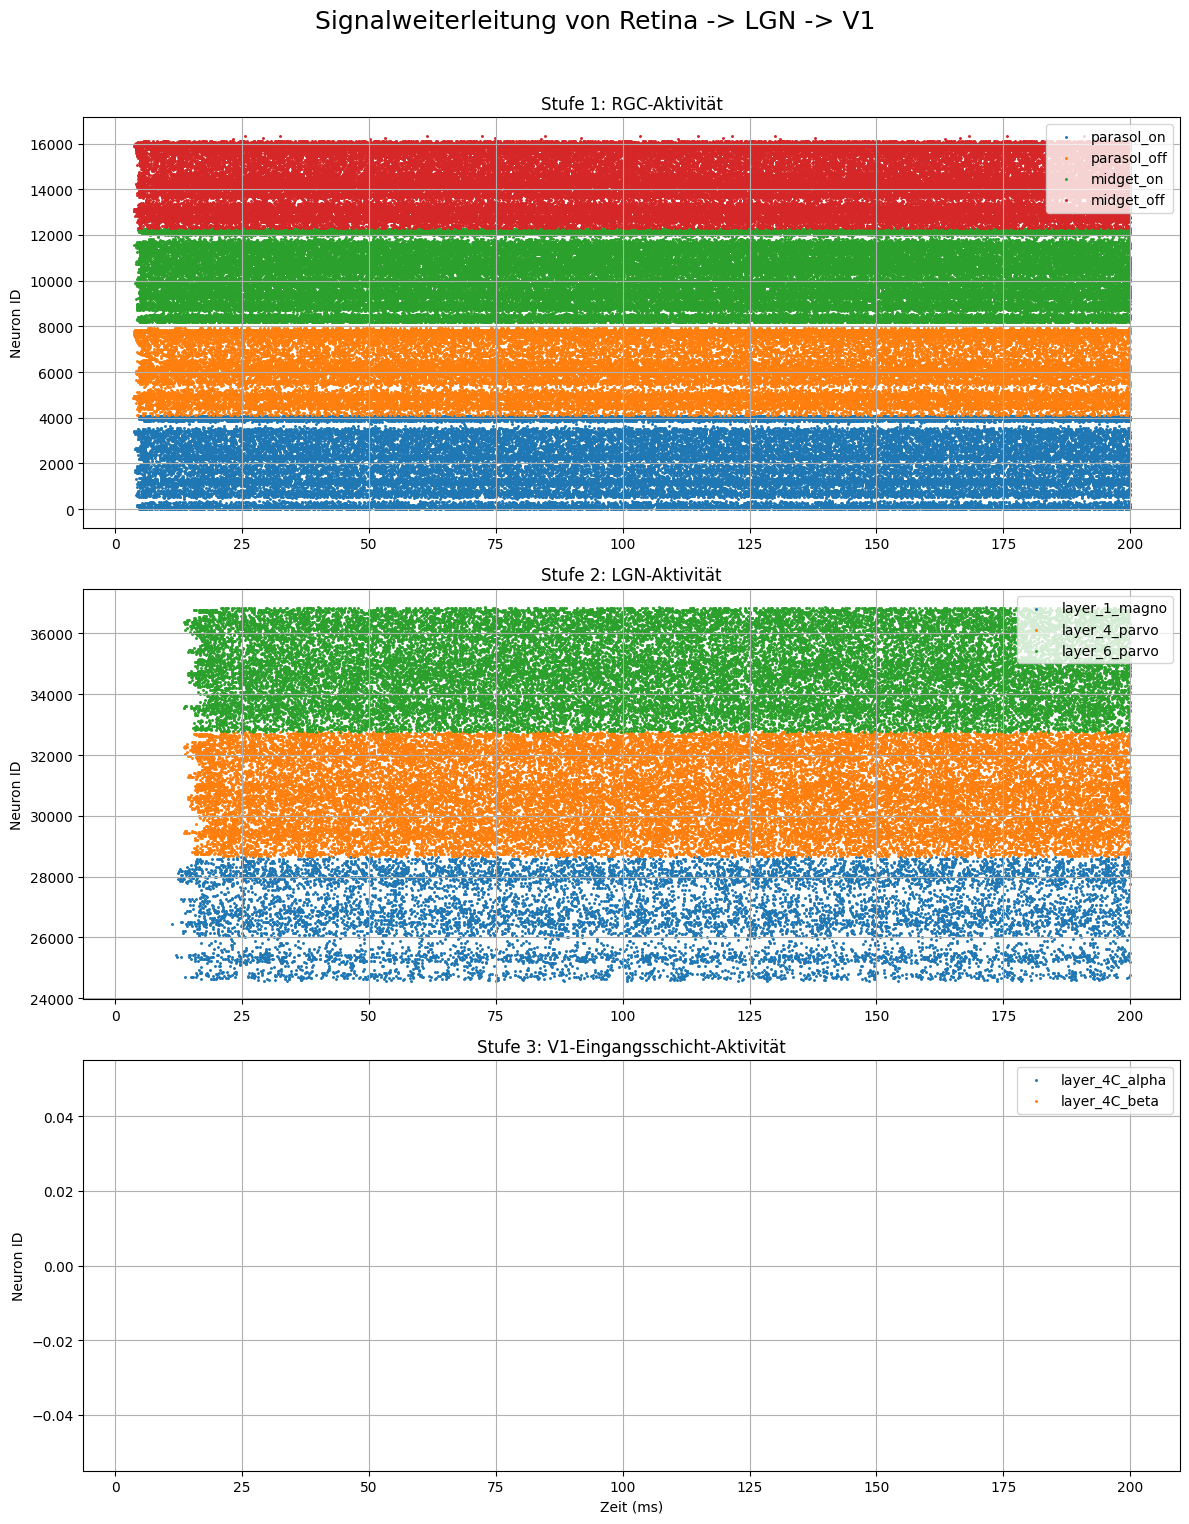

In [12]:
# Block 4 (Update): Hauptskript mit V1


conn_specs_ret_lgn = {
    'm_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.75, 'mask': {'circular': {'radius': 2.5}}}, # von 0.5 auf 0.75
    'p_path_conn': {'rule': 'pairwise_bernoulli', 'p': 0.95, 'mask': {'circular': {'radius': 1.5}}}, # von 0.75 auf 0.95 und Radius vergrößert

    'm_path_syn': {'weight': 85.0, 'delay': 1.2},
    'p_path_syn': {'weight': 65.0, 'delay': 1.2}
}

params_v1 = {"tau_m": 10.0, "V_th": -50.0, "tau_syn_ex": 1.0}
conn_specs_lgn_v1 = {
    'lgn_v1': {'rule': 'pairwise_bernoulli', 'p': 0.15, 'mask': {'circular': {'radius': 2.5}}},
    'lgn_v1_syn': {'weight': 65.0, 'delay': 1.5}
}

conn_specs = {
    'ret_lgn': conn_specs_ret_lgn, # Das alte dict von vorhin
    **conn_specs_lgn_v1 # Das neue für V1
}


nest.ResetKernel()
print("Baue den kompletten visuellen Pathway bis V1 auf...")
pathway = build_visual_pathway(grid_shape, grid_extent, params_rrc, params_lgn, params_v1, conn_specs)
print("-" * 20)


im = Image.open("cat.jpeg")
image_np_bgr = cv2.cvtColor(np.array(im), cv2.COLOR_RGB2BGR)
print("Update der RGC-Inputs mit dem Katzenbild...")
update_rgc_input(image_np_bgr, pathway["retina"]["generators"], target_size=gsl)
nest.Simulate(200.0)
print("Simulation abgeschlossen.")


print("Visualisiere die Aktivität...")
plt.figure(figsize=(12, 16))
plt.suptitle("Signalweiterleitung von Retina -> LGN -> V1", fontsize=18)

# RGC-Aktivität (P- und M-Pfade zusammengefasst)
ax1 = plt.subplot(3, 1, 1)
for name, rec in pathway["retina"]["recorders"].items():
    events = nest.GetStatus(rec, "events")[0]
    ax1.scatter(events['times'], events['senders'], marker='.', s=5, label=name)
ax1.set_title("Stufe 1: RGC-Aktivität")
ax1.set_ylabel("Neuron ID")
ax1.legend(loc='upper right')
ax1.grid(True)

# LGN-Aktivität
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
for name, rec in pathway["lgn"]["recorders"].items():
    events = nest.GetStatus(rec, "events")[0]
    ax2.scatter(events['times'], events['senders'], marker='.', s=5, label=name)
ax2.set_title("Stufe 2: LGN-Aktivität")
ax2.set_ylabel("Neuron ID")
ax2.legend(loc='upper right')
ax2.grid(True)

# V1-Aktivität
ax3 = plt.subplot(3, 1, 3, sharex=ax1)
for name, rec in pathway["v1"]["recorders"].items():
    events = nest.GetStatus(rec, "events")[0]
    ax3.scatter(events['times'], events['senders'], marker='.', s=5, label=name)
ax3.set_title("Stufe 3: V1-Eingangsschicht-Aktivität")
ax3.set_ylabel("Neuron ID")
ax3.set_xlabel("Zeit (ms)")
ax3.legend(loc='upper right')
ax3.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()